# Chapter 14 — Position Sizing & Risk of Ruin

Spec: [`docs/superpowers/specs/2026-05-12-ch14-position-sizing.md`](../docs/superpowers/specs/2026-05-12-ch14-position-sizing.md).

Position sizing turns a probabilistic edge into a dollar bet. We work
on a stipulated synthetic strategy (μ = 1 bp, σ = 7 bp per trade) so
the Kelly, fractional-Kelly, fixed-fractional, and vol-target rules
all have closed-form answers we can check. Then we Monte-Carlo 10,000
paths under each rule and fit a Generalized Pareto Distribution (GPD)
to the per-trade loss tail to bound risk-of-ruin.

## 1. Setup and stipulated strategy

Ch13 left us with an execution stack whose realized edge (after
microstructure costs) was effectively zero. To exercise sizing rules
we stipulate a strategy with a small but real per-trade edge — the
numbers below are not from a backtest, they are a cousin chosen to
make every formula in the chapter non-degenerate.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genpareto

rng = np.random.default_rng(14)              # seeded RNG for reproducibility

# === Stipulated strategy ===
MU_BP = 1.0           # per-trade mean, basis points
SIGMA_BP = 7.0        # per-trade std, basis points
TRADES_PER_SESSION = 6
SESSIONS_PER_YEAR = 252
TPY = TRADES_PER_SESSION * SESSIONS_PER_YEAR   # 1,512 trades/year
N_PATHS = 10_000

mu = MU_BP / 1e4      # 1e-4 in return units (decimal, not bp)
sigma = SIGMA_BP / 1e4

per_trade_sharpe = mu / sigma                    # μ/σ at trade frequency
ann_sharpe_unit = per_trade_sharpe * np.sqrt(TPY)  # √-of-time scaling to annual
print(f"Per-trade Sharpe: {per_trade_sharpe:.4f}")
print(f"Annualized Sharpe (unit notional): {ann_sharpe_unit:.3f}")

Per-trade Sharpe: 0.1429
Annualized Sharpe (unit notional): 5.555


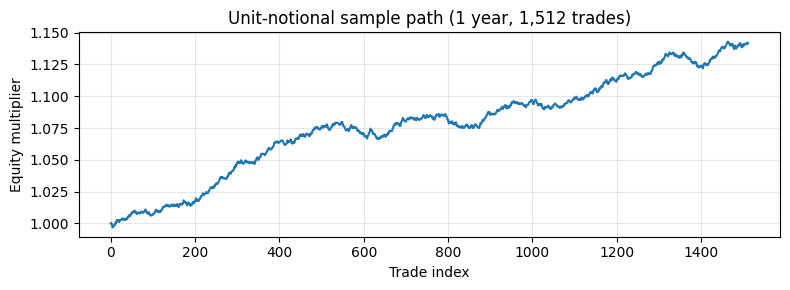

In [2]:
# One sample equity path at unit notional over a full year.
# Compounding (1 + r) trade-by-trade gives the realized equity multiplier.
# Reseed at major MC entry points so cells are independently reproducible.
rng = np.random.default_rng(14)
eq = np.cumprod(1 + rng.normal(mu, sigma, TPY))
plt.figure(figsize=(8, 3))
plt.plot(np.concatenate([[1.0], eq]))           # prepend the starting 1.0
plt.title("Unit-notional sample path (1 year, 1,512 trades)")
plt.xlabel("Trade index")
plt.ylabel("Equity multiplier")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Kelly

For a strategy with continuously compounded per-trade return $r \sim
\mathcal{N}(\mu, \sigma^2)$, the Kelly fraction maximizing
log-equity growth is

$$f^{*} = \mu / \sigma^{2}, \qquad g^{*} = \tfrac{1}{2}\,\mu^{2}/\sigma^{2}.$$

where:
- $f^{*}$ — per-trade fraction of equity to bet (a leverage multiplier when $f^* > 1$)
- $g^{*}$ — log-growth rate per trade at the optimal fraction
- $\mu, \sigma$ — per-trade mean and std of return (in decimal, not bp)

A careful warning is coming: Kelly's textbook derivation assumes
$|f\cdot r| \ll 1$, the small-bet regime. On a bp-scale strategy
the formula misbehaves.

In [3]:
# === §2 Kelly ===
f_kelly = mu / sigma**2
g_kelly = 0.5 * mu**2 / sigma**2   # ½·μ²/σ² growth rate at f*
print(f"Full-Kelly f* per trade: {f_kelly:.6f}  (~{f_kelly*100:.2f}% of equity)")
print(f"Full-Kelly growth rate g*: {g_kelly:.6e} per trade")
print(f"Annualized growth at full-Kelly: {g_kelly * TPY:.4f}  (~{(np.exp(g_kelly*TPY)-1)*100:.1f}%)")

# Growth vs leverage multiplier k (k=1 is full-Kelly, k=2 is overbet to zero growth)
k_grid = np.linspace(0, 3, 61)
g_k = (k_grid * f_kelly) * mu - 0.5 * (k_grid * f_kelly)**2 * sigma**2

Full-Kelly f* per trade: 204.081633  (~20408.16% of equity)
Full-Kelly growth rate g*: 1.020408e-02 per trade
Annualized growth at full-Kelly: 15.4286  (~501814664.5%)


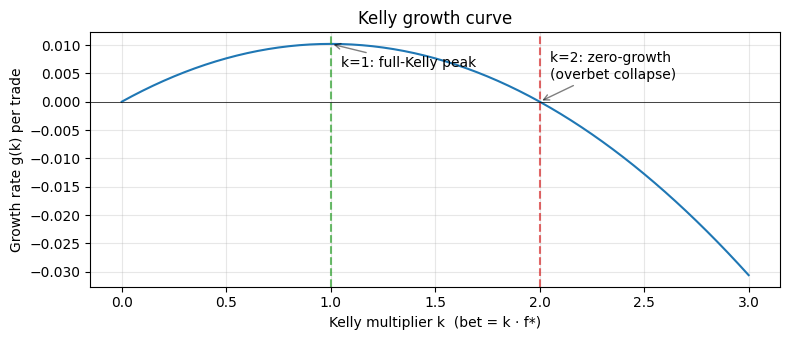

In [4]:
# g(k) is a parabola in the leverage multiplier k.
# Peak at k=1 (full Kelly); zero crossings at k=0 and k=2 (overbetting collapse).
plt.figure(figsize=(8, 3.5))
plt.plot(k_grid, g_k)
plt.axvline(1, color="C2", linestyle="--", alpha=0.7)
plt.axvline(2, color="C3", linestyle="--", alpha=0.7)
plt.axhline(0, color="black", linewidth=0.5)
plt.annotate("k=1: full-Kelly peak", xy=(1, g_kelly), xytext=(1.05, g_kelly * 0.6),
             arrowprops=dict(arrowstyle="->", alpha=0.5))
plt.annotate("k=2: zero-growth\n(overbet collapse)", xy=(2, 0), xytext=(2.05, g_kelly * 0.4),
             arrowprops=dict(arrowstyle="->", alpha=0.5))
plt.xlabel("Kelly multiplier k  (bet = k · f*)")
plt.ylabel("Growth rate g(k) per trade")
plt.title("Kelly growth curve")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# f·σ is the per-trade equity-at-risk per σ of return. Safe operation: f·σ ≪ 1.
f_times_sigma = f_kelly * sigma
print(f"f* · σ at full-Kelly: {f_times_sigma:.4f}")
print(f"1σ-loss-at-full-Kelly: -{f_kelly * sigma * 100:.2f}% of equity")
print(f"3σ-loss-at-full-Kelly: -{f_kelly * 3 * sigma * 100:.2f}% of equity")

f* · σ at full-Kelly: 0.1429
1σ-loss-at-full-Kelly: -14.29% of equity
3σ-loss-at-full-Kelly: -42.86% of equity


In [6]:
# Compare {full, half, quarter}-Kelly on the f·σ diagnostic.
# Each row shows the leverage and the per-trade equity at risk per σ.
rows_k = []
for label, k in [("Full Kelly", 1.0), ("Half Kelly", 0.5), ("Quarter Kelly", 0.25)]:
    f_k = k * f_kelly
    rows_k.append({"rule": label, "f": f_k, "f·σ": f_k * sigma,
                   "1σ-loss": f_k * sigma, "3σ-loss": 3 * f_k * sigma})
print(pd.DataFrame(rows_k).to_string(index=False, float_format=lambda x: f"{x:.4f}"))

         rule        f    f·σ  1σ-loss  3σ-loss
   Full Kelly 204.0816 0.1429   0.1429   0.4286
   Half Kelly 102.0408 0.0714   0.0714   0.2143
Quarter Kelly  51.0204 0.0357   0.0357   0.1071


## 3. Fixed-fractional and fixed-dollar

The trader's rule of thumb $f = \text{risk\%} / \text{stop-distance}$
ignores $\mu$ entirely. It's simpler than Kelly but suffers the
*same* unit-sensitivity problem when the stop is measured at
per-trade σ.

In [7]:
# === §3 Fixed-fractional ===
# Risk 2% of equity per trade, stop distance d = 1·sigma (in return units).
RISK_PER_TRADE = 0.02
STOP_DIST = sigma  # 1σ stop in return units
f_fixed_frac = RISK_PER_TRADE / STOP_DIST
print(f"Fixed-fractional (2% risk, 1σ stop) fraction: {f_fixed_frac:.4f}")
# Note: f=28.6 is also over-levered. The fix is to use a session-scale or
# day-scale stop, not 1σ-per-trade. The teaching point is identical to
# Kelly's: f must be measured against the SAME horizon as the loss budget.

Fixed-fractional (2% risk, 1σ stop) fraction: 28.5714


## 4. Vol targeting

Set leverage so daily PnL has a target std (e.g. 1% per day). Derives
position size from σ, not from μ/σ², so it's immune to the
unit-sensitivity gotcha that broke Kelly above.

In [8]:
# === §4 Vol targeting ===
# Daily PnL std at unit notional = σ_trade · √(trades/session)
sigma_daily = sigma * np.sqrt(TRADES_PER_SESSION)
TARGET_DAILY_VOL = 0.01   # 1% daily
target_lev = TARGET_DAILY_VOL / sigma_daily
print(f"Daily PnL std (unit notional): {sigma_daily*1e4:.2f} bp")
print(f"Vol-target leverage at 1% daily vol: {target_lev:.2f}x")
# Vol targeting produces the only sane leverage on this strategy because it
# derives leverage from σ, not μ/σ².

Daily PnL std (unit notional): 17.15 bp
Vol-target leverage at 1% daily vol: 5.83x


## 5. Drawdown control and Monte-Carlo comparison

Drawdown stops on a stationary positive-EV strategy are strictly
suboptimal: they cut you off from compounding precisely after a
normal adverse run. Their real job is **regime-change detection** —
the signal that the strategy has stopped working. We'll quantify the
growth-vs-DD trade explicitly below.

In [9]:
# === Simulate MC paths under each rule ===
# 10,000 paths x 1,512 trades. r_t ~ N(mu, sigma^2). Equity multiplied by (1 + f*r_t).
# Reseed at major MC entry points so cells are independently reproducible.
rng = np.random.default_rng(14)
all_returns = rng.normal(mu, sigma, size=(N_PATHS, TPY))

def equity_curves(f_per_trade, returns):
    # Compound equity under fixed per-trade leverage f.
    eq = np.cumprod(1.0 + f_per_trade * returns, axis=1)
    eq = np.concatenate([np.ones((eq.shape[0], 1)), eq], axis=1)   # prepend t=0 equity = 1
    return eq

def max_drawdown(eq):
    # Max drawdown across each row of an equity matrix.
    peak = np.maximum.accumulate(eq, axis=1)    # running peak per path
    dd = (eq - peak) / peak                     # drawdown is non-positive
    return -dd.min(axis=1)                      # return positive fraction

def summarize(eq, label):
    mdd = max_drawdown(eq)
    final = eq[:, -1]
    # Equity Sharpe: (mean log-return) / (std log-return) x sqrt(periods/year)
    per_trade_log = np.diff(np.log(eq), axis=1)
    s = per_trade_log.mean(axis=1) / per_trade_log.std(axis=1) * np.sqrt(TPY)
    return {
        "rule": label,
        "mean_final": final.mean(),
        "median_mdd": np.median(mdd),
        "p95_mdd": np.quantile(mdd, 0.95),
        "frac_dd_ge_20pct": (mdd >= 0.20).mean(),
        "frac_dd_ge_50pct": (mdd >= 0.50).mean(),
        "mean_sharpe": s.mean(),
    }

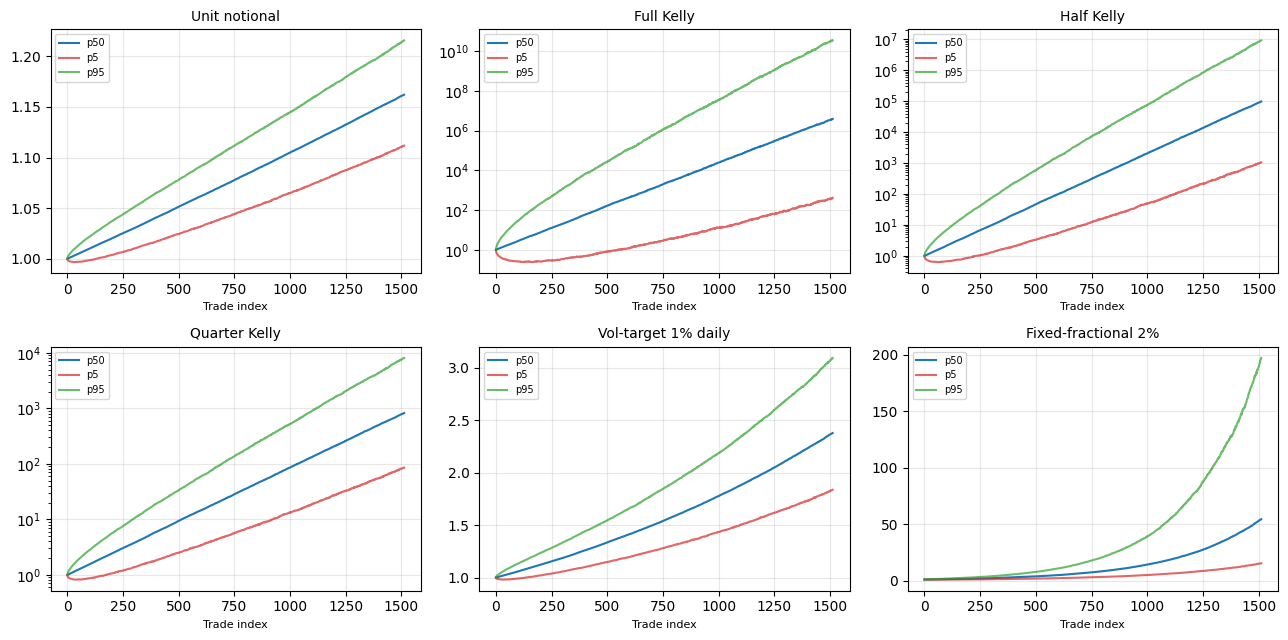

In [10]:
# Fan charts: p5 / p50 / p95 across time for each rule.
# Kelly variants span 10⁶+ orders of magnitude, so they get log-y axes.
fan_specs = [
    ("Unit notional", 1.0, False),
    ("Full Kelly", f_kelly, True),
    ("Half Kelly", 0.5 * f_kelly, True),
    ("Quarter Kelly", 0.25 * f_kelly, True),
    ("Vol-target 1% daily", target_lev, False),
    ("Fixed-fractional 2%", f_fixed_frac, False),
]
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
t_axis = np.arange(TPY + 1)
for ax, (label, f_, log_y) in zip(axes.flat, fan_specs):
    eq = equity_curves(f_, all_returns)
    p5  = np.quantile(eq, 0.05, axis=0)
    p50 = np.quantile(eq, 0.50, axis=0)
    p95 = np.quantile(eq, 0.95, axis=0)
    ax.plot(t_axis, p50, color="C0", label="p50")
    ax.plot(t_axis, p5,  color="C3", alpha=0.7, label="p5")
    ax.plot(t_axis, p95, color="C2", alpha=0.7, label="p95")
    if log_y:
        ax.set_yscale("log")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Trade index", fontsize=8)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc="best")
plt.tight_layout()
plt.show()

In [11]:
rows = []
for label, f in [
    ("Unit notional", 1.0),
    ("Full Kelly", f_kelly),
    ("Half Kelly", 0.5 * f_kelly),
    ("Quarter Kelly", 0.25 * f_kelly),
    ("Fixed-fractional 2%", f_fixed_frac),
    (f"Vol-target tau_daily=0.63% ({0.0063/sigma_daily:.2f}x)", 0.0063 / sigma_daily),
    (f"Vol-target tau_daily=1.0% ({target_lev:.2f}x)", target_lev),
]:
    eq = equity_curves(f, all_returns)
    rows.append(summarize(eq, label))

df = pd.DataFrame(rows)
print("=== Side-by-side comparison (7 base rules) ===")
print(df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

=== Side-by-side comparison (7 base rules) ===
                              rule         mean_final  median_mdd  p95_mdd  frac_dd_ge_20pct  frac_dd_ge_50pct  mean_sharpe
                     Unit notional             1.1628      0.0103   0.0162            0.0000            0.0000       5.5348
                        Full Kelly 1956229649672.1147      0.9591   0.9963            1.0000            1.0000       2.7286
                        Half Kelly       4400561.7249      0.7167   0.8748            1.0000            0.9955       4.1666
                     Quarter Kelly          2163.4241      0.4356   0.6035            1.0000            0.2469       4.8633
               Fixed-fractional 2%            74.0295      0.2654   0.3895            0.9202            0.0026       5.1660
Vol-target tau_daily=0.63% (3.67x)             1.7405      0.0374   0.0586            0.0000            0.0000       5.4992
 Vol-target tau_daily=1.0% (5.83x)             2.4099      0.0589   0.0918           

In [12]:
# Drawdown-stop variants on the Half-Kelly base.
# halve_at: relative DD at which leverage is halved
# recover_within: relative-to-peak threshold for un-halving
# halt_at: absolute kill-switch DD (no recovery)
def simulate_with_stop(f0, returns, halve_at=0.05, recover_within=0.02, halt_at=None):
    eq = np.ones((returns.shape[0], returns.shape[1] + 1))
    peak = np.ones(returns.shape[0])
    halved = np.zeros(returns.shape[0], dtype=bool)
    halted = np.zeros(returns.shape[0], dtype=bool)
    for t in range(returns.shape[1]):
        f_eff = np.where(halted, 0.0, np.where(halved, 0.5 * f0, f0))
        eq[:, t + 1] = eq[:, t] * (1.0 + f_eff * returns[:, t])
        peak = np.maximum(peak, eq[:, t + 1])
        dd = (peak - eq[:, t + 1]) / peak
        if halt_at is not None:
            halted |= dd >= halt_at
        halved = (halved | (dd >= halve_at)) & (dd > recover_within)
    return eq

eq_hk_halve = simulate_with_stop(0.5 * f_kelly, all_returns, halve_at=0.05, recover_within=0.02)
rows.append(summarize(eq_hk_halve, "Half-Kelly + halve-on-5%"))
eq_hk_halt = simulate_with_stop(0.5 * f_kelly, all_returns, halt_at=0.10)
rows.append(summarize(eq_hk_halt, "Half-Kelly + halt-on-10%"))

df = pd.DataFrame(rows)
print("=== Side-by-side comparison (with stop variants, 9 rows) ===")
print(df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

=== Side-by-side comparison (with stop variants, 9 rows) ===
                              rule         mean_final  median_mdd  p95_mdd  frac_dd_ge_20pct  frac_dd_ge_50pct  mean_sharpe
                     Unit notional             1.1628      0.0103   0.0162            0.0000            0.0000       5.5348
                        Full Kelly 1956229649672.1147      0.9591   0.9963            1.0000            1.0000       2.7286
                        Half Kelly       4400561.7249      0.7167   0.8748            1.0000            0.9955       4.1666
                     Quarter Kelly          2163.4241      0.4356   0.6035            1.0000            0.2469       4.8633
               Fixed-fractional 2%            74.0295      0.2654   0.3895            0.9202            0.0026       5.1660
Vol-target tau_daily=0.63% (3.67x)             1.7405      0.0374   0.0586            0.0000            0.0000       5.4992
 Vol-target tau_daily=1.0% (5.83x)             2.4099      0.0589   0.0

## 6. EVT sidebar: tail shape and risk-of-ruin

We fit a Generalized Pareto Distribution (GPD) to the per-trade loss
tail (peaks-over-threshold, $u$ = 95th percentile). The shape
parameter $\hat\xi$ tells us which tail-domain we're in: $\hat\xi <
0$ short / bounded tail, $\hat\xi > 0$ heavy / Pareto tail.

Because MC P(DD ≥ X) saturates at 1.0 under full-Kelly leverage, we
run the EVT-vs-MC comparison at the *vol-target* leverage (5.83×)
instead — the only place the comparison is non-degenerate on this
strategy.

In [13]:
# === §6 EVT risk-of-ruin sidebar ===
# Fit GPD to the lower tail of per-trade returns (left tail = losses).
losses = -all_returns.flatten()         # losses are positive
u = np.quantile(losses, 0.95)           # peaks-over-threshold at p95
tail = losses[losses > u] - u           # exceedances above u
xi_hat, _, sigma_hat = genpareto.fit(tail, floc=0)
print(f"GPD fit on synthetic left tail (u=p95): xi_hat={xi_hat:+.3f}, sigma_hat={sigma_hat:.6e}")

GPD fit on synthetic left tail (u=p95): xi_hat=-0.120, sigma_hat=3.275294e-04


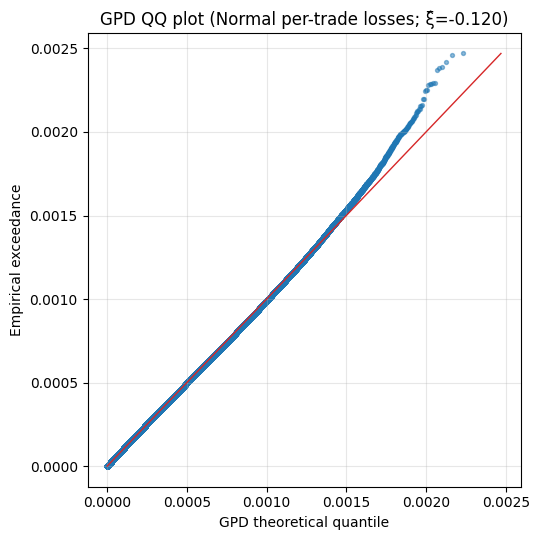

In [14]:
# QQ plot: empirical exceedances vs GPD theoretical quantiles.
# A good fit lies on the y = x line.
emp = np.sort(tail)
theo = genpareto.ppf((np.arange(len(emp)) + 0.5) / len(emp), c=xi_hat, scale=sigma_hat)
plt.figure(figsize=(5.5, 5.5))
plt.scatter(theo, emp, s=8, alpha=0.5)
lo, hi = 0, max(theo.max(), emp.max())
plt.plot([lo, hi], [lo, hi], color="C3", linewidth=1)
plt.xlabel("GPD theoretical quantile")
plt.ylabel("Empirical exceedance")
plt.title(f"GPD QQ plot (Normal per-trade losses; ξ̂={xi_hat:+.3f})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# CC-3: MC P(DD >= X) at VOL-TARGET leverage (5.83x), not full-Kelly.
# Full-Kelly saturates these probabilities at 1.0; vol-target is non-degenerate.
mdd_vt = max_drawdown(equity_curves(target_lev, all_returns))
print(f"Vol-target leverage = {target_lev:.2f}x")
for X in [0.10, 0.20, 0.30, 0.50]:
    p_mc = (mdd_vt >= X).mean()
    print(f"  P_MC(DD >= {X*100:.0f}% | vol-target) = {p_mc:.4f}")
# Note: EVT on per-trade losses doesn't translate directly to max-DD
# (max-DD is a path functional, not a single-event quantity). What EVT
# gives us is a worst-single-event bound: at vol-target leverage, a 99.9th-pct
# per-trade loss costs target_lev * loss in equity per trade.
print()
# POT 99.9th-pct quantile:  q_p = u + (sigma/xi) * (((N/Nu)*(1-p))^(-xi) - 1)
N = losses.size
Nu = tail.size
p = 0.999
q_999 = u + (sigma_hat / xi_hat) * (((N / Nu) * (1 - p)) ** (-xi_hat) - 1)
print(f"POT 99.9th-pct single-trade loss (Normal):    {q_999:.6f}  ({q_999*1e4:.2f} bp)")
print(f"At vol-target leverage that equity hit is:    {target_lev * q_999 * 100:.3f}% of equity")

Vol-target leverage = 5.83x
  P_MC(DD >= 10% | vol-target) = 0.0292
  P_MC(DD >= 20% | vol-target) = 0.0000
  P_MC(DD >= 30% | vol-target) = 0.0000
  P_MC(DD >= 50% | vol-target) = 0.0000

POT 99.9th-pct single-trade loss (Normal):    0.002073  (20.73 bp)
At vol-target leverage that equity hit is:    1.209% of equity


In [16]:
# Student-t for Exercise 3: matched-variance heavier tail.
rng_t = np.random.default_rng(99)
DF = 4
t_raw = rng_t.standard_t(DF, size=(N_PATHS, TPY))
t_scale = sigma * np.sqrt((DF - 2) / DF)   # rescale to match Normal variance
t_returns = mu + t_scale * t_raw
losses_t = -t_returns.flatten()
u_t = np.quantile(losses_t, 0.95)
tail_t = losses_t[losses_t > u_t] - u_t
xi_t, _, sigma_t = genpareto.fit(tail_t, floc=0)
print(f"GPD fit on Student-t(df=4) left tail: xi_hat={xi_t:+.3f}, sigma_hat={sigma_t:.6e}")
print()
print(f"Sign flip: Normal ξ̂={xi_hat:+.3f} (bounded/Weibull tail)")
print(f"           t(df=4) ξ̂={xi_t:+.3f} (heavy/Frechet tail)")
print("Same variance, fundamentally different worst-case behavior.")

GPD fit on Student-t(df=4) left tail: xi_hat=+0.192, sigma_hat=4.276394e-04

Sign flip: Normal ξ̂=-0.120 (bounded/Weibull tail)
           t(df=4) ξ̂=+0.192 (heavy/Frechet tail)
Same variance, fundamentally different worst-case behavior.


## 7. Summary side-by-side

Below is the final 9-row table (7 base rules + 2 drawdown-stop
variants on Half-Kelly). Two interpretive points before you read it:
(a) **median MDD** is the honest center of the drawdown distribution;
*mean final* is misleading because Kelly-family rules are dominated
by a handful of lottery winners. (b) The row labelled
`Vol-target tau_daily=1.0%` (the §4 baseline at ~5.83×) is the
chapter's recommended rule — it keeps both median MDD and p95 MDD
in a sane range. We also show `Vol-target tau_daily=0.63%` (~3.67×)
so the leverage knob is visible: halving the vol target halves the
leverage and roughly halves the drawdown bands.

In [17]:
print(df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

                              rule         mean_final  median_mdd  p95_mdd  frac_dd_ge_20pct  frac_dd_ge_50pct  mean_sharpe
                     Unit notional             1.1628      0.0103   0.0162            0.0000            0.0000       5.5348
                        Full Kelly 1956229649672.1147      0.9591   0.9963            1.0000            1.0000       2.7286
                        Half Kelly       4400561.7249      0.7167   0.8748            1.0000            0.9955       4.1666
                     Quarter Kelly          2163.4241      0.4356   0.6035            1.0000            0.2469       4.8633
               Fixed-fractional 2%            74.0295      0.2654   0.3895            0.9202            0.0026       5.1660
Vol-target tau_daily=0.63% (3.67x)             1.7405      0.0374   0.0586            0.0000            0.0000       5.4992
 Vol-target tau_daily=1.0% (5.83x)             2.4099      0.0589   0.0918            0.0000            0.0000       5.4704
        

## 8. So what — three decision rules

1. **Compute Kelly, but cap at quarter-Kelly or use it as a noise
   diagnostic.** If $f^{*}\cdot\sigma \gtrsim 0.02$, the textbook
   small-bet derivation has broken; size with something else.
2. **Vol target as the operational baseline.** Set $\tau_{daily}$ to
   the equity-vol you can tolerate, derive leverage from $\hat\sigma_t$,
   re-estimate at session boundaries.
3. **MC ruin simulation before going live.** 10,000-path MC under
   your sizing rule, on synthetic returns matching your edge and σ.
   If P(DD ≥ X) at your DD limit is above what your investors will
   tolerate, your sizing is too aggressive — regardless of what the
   Sharpe says.

### Key Terms

- **Kelly fraction $f^{*}$** — bet size maximizing log-equity growth: $\mu/\sigma^2$ for Normal returns.
- **Fractional Kelly** — bet $k\cdot f^{*}$ for $k \in (0, 1)$; trades growth for drawdown reduction.
- **Fixed-fractional sizing** — bet a fixed % of equity, with size determined by a stop distance: $f = \text{risk\%}/\text{stop}$.
- **Vol targeting** — set leverage so realized portfolio vol matches a target (e.g. 1%/day).
- **Drawdown stop** — halve or halt the strategy when running drawdown exceeds a threshold.
- **GPD shape $\hat\xi$** — tail-index estimate; $<0$ bounded, $=0$ exponential, $>0$ Pareto/heavy.
- **Risk of ruin** — probability of breaching a terminal-loss threshold over a horizon.

### Up next

- **Ch15** sharpens $\hat\sigma_t$ — the input to vol-targeting. The
  better $\hat\sigma_t$ is, the lower the lag between regime shift
  and sizing response.
- **Ch16** stops working on stipulated cousins and introduces real
  edge candidates — momentum, breakout, event-driven — whose
  per-trade $\mu$ is small enough that $f^{*}\cdot\sigma$ lands in
  the safe operating range.

## Exercises

1. **Kelly's sensitivity to μ misestimate.** SE on μ̂ from
   N=1,500 trades is σ/√1500 ≈ 1.81×10⁻⁵.
   Compute f\*(μ̂) = μ̂/σ² and growth rate
   g(f\*) = f\*·μ<sub>true</sub> − ½·(f\*)²·σ²
   at each f\* (using the *true* μ). Plot f\*(μ̂) and
   g(f\*(μ̂)) over μ̂ ∈ [μ − 2·SE, μ + 2·SE].
   Show that +1-SE optimism over-states leverage by ~18% and
   costs ~3% of peak growth; +2-SE optimism over-states leverage
   by ~36% and costs ~13% of peak growth. Identify the
   μ̂ at which g(f\*) = 0 and express it in SE units (it
   sits well outside the ±2·SE band).
2. **Vol targeting under regime shift.** Generate a synthetic 1-year
   session-bar series where true σ doubles at t=0.5. Run
   vol targeting with 20-day rolling σ̂<sub>t</sub> and
   τ<sub>daily</sub>=1%. Plot realized-vol vs target-vol; document the
   lag (in days) before realized catches up, and the over-leveraged
   window's max DD.
3. **Empirical-MC vs GPD-extrapolated P(DD ≥ 20%).**
   Compute both on the stipulated strategy *at vol-target leverage
   5.83×* (not full-Kelly — full-Kelly saturates MC). Then redo with
   Student-t(df=4) per-trade returns at matched variance. Document
   the gap that opens at deep-DD thresholds (P(DD ≥ 30%),
   P(DD ≥ 50%)) when the tail is fat.
4. **Half-Kelly vs vol-target at matched ex-ante leverage.** Pick
   τ<sub>vol</sub> such that vol-target's leverage equals half-Kelly's
   leverage (~102 here). Compare max-DD distributions. Which is
   preferable and why? (Hint: they should be near-identical because
   at matched leverage they bet the same fraction; the framing
   differences vanish — at the same leverage, both rules produce
   statistically identical paths.)

### Exercise 1 — Worked solution

With $\sigma = 7\!\times\!10^{-4}$, the SE on $\hat\mu$ from
$N=1{,}500$ trades is $\sigma/\sqrt{1500}\approx 1.81\!\times\!10^{-5}$.
At a biased estimate $\hat\mu$, the operator picks leverage
$f^{*}(\hat\mu) = \hat\mu/\sigma^{2}$; the *true* growth at that bet is

$$
g_{\text{true}}(f^{*}) \;=\; f^{*}\!\cdot\!\mu - \tfrac{1}{2}(f^{*})^{2}\sigma^{2}
\;=\; \frac{\hat\mu\,(2\mu - \hat\mu)}{2\sigma^{2}},
$$

which is zero at $\hat\mu = 0$ and at $\hat\mu = 2\mu$. Translating
the non-trivial zero into SE units: $(2\mu - \mu)/SE = \mu/SE
\approx +5.53\,SE$ (equivalently, per-trade Sharpe $\cdot \sqrt{N}
= 0.143\cdot\sqrt{1500} \approx 5.53$). A $+5.53\,SE$ estimation error
has probability $\Phi(-5.53)\approx 1.6\!\times\!10^{-8}$ under
$N(\mu, SE^{2})$ — vanishingly rare.

So on a strategy this well-estimated, the realistic concern is not
hitting the zero-growth crossing but paying steady growth *drag*:
at $+1\,SE$ optimism, $g_{\text{true}}$ falls to $\sim 97\%$ of its
peak (a $\sim 3\%$ penalty); at $+2\,SE$ optimism, to $\sim 87\%$
of peak (a $\sim 13\%$ penalty for a $\sim 2.3\%$-probability event). The pedagogical lesson is unchanged: optimistic $\hat\mu$
produces over-leverage and a measurable growth penalty, even before
you reach the (extremely rare) zero crossing. The remedy is the
same — divide your Kelly fraction by 2–4. And on *this* strategy,
the unit-sensitivity gotcha from §2 dominates the estimation-noise
concern anyway: with $f\cdot\sigma = 0.14$ at full-Kelly, even a
perfectly known $\hat\mu$ would over-lever the bet toward ruin.

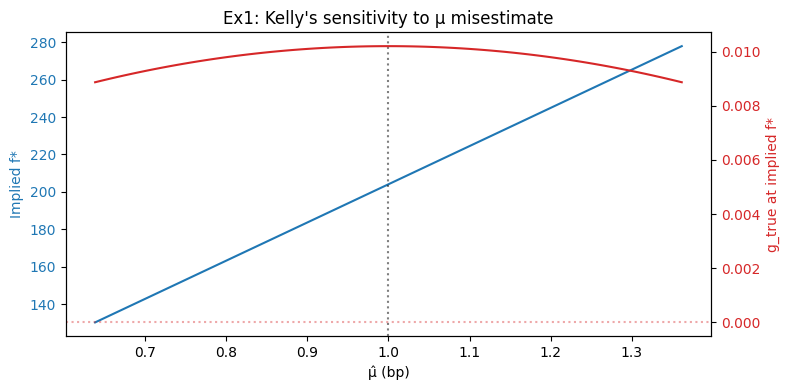

μ̂ = μ + -1·SE = 0.819 bp  =>  f* =  167.20  g_true = +0.009871
μ̂ = μ + +1·SE = 1.181 bp  =>  f* =  240.97  g_true = +0.009871
μ̂ = μ + +2·SE = 1.361 bp  =>  f* =  277.85  g_true = +0.008871


In [18]:
SE = sigma / np.sqrt(1500)                       # SE on mu-hat from 1,500 trades
mu_hat_grid = np.linspace(mu - 2*SE, mu + 2*SE, 81)
f_star_hat = mu_hat_grid / sigma**2                  # implied Kelly under noisy mu-hat
g_true_at_f = f_star_hat * mu - 0.5 * f_star_hat**2 * sigma**2  # true growth at that bet

# Where does g_true cross zero on the upside?
# g_true(f) = 0 at f = 2·mu/sigma^2 = 2·f_kelly => mu_hat = 2·mu.
# That's well outside ±2SE on this strategy; we still show the curve dipping.
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(mu_hat_grid * 1e4, f_star_hat, color="C0", label="implied f*(μ̂)")
ax1.axvline(mu * 1e4, color="black", linestyle=":", alpha=0.5)
ax1.set_xlabel("μ̂ (bp)")
ax1.set_ylabel("Implied f*", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")
ax2 = ax1.twinx()
ax2.plot(mu_hat_grid * 1e4, g_true_at_f, color="C3", label="g_true(f*(μ̂))")
ax2.axhline(0, color="C3", linestyle=":", alpha=0.4)
ax2.set_ylabel("g_true at implied f*", color="C3")
ax2.tick_params(axis="y", labelcolor="C3")
plt.title("Ex1: Kelly's sensitivity to μ misestimate")
plt.tight_layout()
plt.show()

# Numerical readout at +1 SE and +2 SE
for k_se in [-1, +1, +2]:
    mu_hat = mu + k_se * SE
    f_imp = mu_hat / sigma**2
    g_t = f_imp * mu - 0.5 * f_imp**2 * sigma**2
    print(f"μ̂ = μ + {k_se:+d}·SE = {mu_hat*1e4:.3f} bp  =>  f* = {f_imp:7.2f}  g_true = {g_t:+.6f}")

### Exercise 3 — Worked solution

At vol-target leverage 5.83×, compute MC $P(\text{DD} \geq X)$ for
$X \in \{10\%, 20\%, 30\%, 50\%\}$ under Normal and matched-variance
Student-t(df=4) per-trade returns. Then fit GPD to per-trade losses
under each DGP. The Student-t tail (heavier) should push the deep-DD
probabilities up.

In [19]:
# Reseed for independent reproducibility — mirrors §5/§6 seeds.
rng = np.random.default_rng(14)
all_returns = rng.normal(mu, sigma, size=(N_PATHS, TPY))
rng_t = np.random.default_rng(99)
t_raw = rng_t.standard_t(DF, size=(N_PATHS, TPY))
t_scale_local = sigma * np.sqrt((DF - 2) / DF)
t_returns = mu + t_scale_local * t_raw

print(f"Vol-target leverage = {target_lev:.2f}x")
print()
print(f"{'X':>5} | P_MC Normal | P_MC t(df=4)")
print("-" * 38)
for X in [0.10, 0.20, 0.30, 0.50]:
    p_n = (max_drawdown(equity_curves(target_lev, all_returns)) >= X).mean()
    p_t = (max_drawdown(equity_curves(target_lev, t_returns))   >= X).mean()
    print(f"{X*100:4.0f}% |   {p_n:7.4f}   |   {p_t:7.4f}")

print()
print(f"GPD ξ̂ on Normal per-trade losses:    {xi_hat:+.3f}")
print(f"GPD ξ̂ on Student-t(df=4) losses:    {xi_t:+.3f}")
print()
print("Heavier tail (ξ̂ > 0) shifts mass into deep-DD events at MATCHED variance.")
print("EVT shape parameter is the right summary — variance is not.")

Vol-target leverage = 5.83x

    X | P_MC Normal | P_MC t(df=4)
--------------------------------------


  10% |    0.0292   |    0.0360


  20% |    0.0000   |    0.0002


  30% |    0.0000   |    0.0001


  50% |    0.0000   |    0.0000

GPD ξ̂ on Normal per-trade losses:    -0.120
GPD ξ̂ on Student-t(df=4) losses:    +0.192

Heavier tail (ξ̂ > 0) shifts mass into deep-DD events at MATCHED variance.
EVT shape parameter is the right summary — variance is not.
